 مشروع قياس درجة الإرهاق باستخدام الرؤية الحاسوبية


يهدف النظام إلى تحليل صور الوجوه البشرية وتقدير درجة الإرهاق اعتمادًا على:

- حالة العينين
- نسبة إغلاق العين
- فتح الفم (التثاؤب)
- خصائص الوجه العامة

تم استخدام تقنيات:

- Pre-processing
- Haar Cascade Detection
- Thresholding
- Morphological Operations
- Segmentation

لتحديد مستوى التعب بشكل تقريبي.



## 1. استيراد المكتبات اللازمة

نستخدم:

- `OpenCV` لمعالجة الصور وكشف الوجه والعينين
- `NumPy` للعمليات الحسابية
- `Matplotlib` لعرض النتائج داخل الـ Notebook


In [1]:

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline



## 2. المعالجة الأولية (Pre-processing)

في هذه المرحلة يتم:

1. قراءة الصورة
2. تحويلها إلى تدرج رمادي
3. تحسين الإضاءة باستخدام Histogram Equalization
4. تطبيق Gaussian Blur لتخفيف الضجيج



In [2]:

def preprocess_image(image_path):

    img = cv.imread(image_path)

    if img is None:
        return None, None

    # تحويل إلى رمادي
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # تحسين الإضاءة
    gray = cv.equalizeHist(gray)

    # تنعيم الصورة
    blurred = cv.GaussianBlur(gray, (5, 5), 0)

    return img, blurred



## 3. كشف الوجه والعينين (Object Detection)

نستخدم خوارزمية Haar Cascade المذكورة في Lecture 8
من أجل كشف:

- الوجه
- العينين



In [3]:
face_cascade = cv.CascadeClassifier(
    cv.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

eye_cascade = cv.CascadeClassifier(
    cv.data.haarcascades +
    'haarcascade_eye.xml'
)



## 4. تحليل الإرهاق (Fatigue Analysis)

يتم تحليل الإرهاق اعتمادًا على:

- إغلاق العين
- عدم كشف العينين
- التثاؤب (فتح الفم)

باستخدام:

- Thresholding
- Morphological Operations
- Pixel Ratio Analysis



In [4]:
def analyze_fatigue(img, blurred):

    faces = face_cascade.detectMultiScale(
        blurred,
        1.2,
        5
    )

    if len(faces) == 0:
        return -1, "No Face Detected"

    fatigue_score = 0

    for (x, y, w, h) in faces:

        # رسم مستطيل الوجه
        cv.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        roi_gray = blurred[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        # كشف العينين
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=4
        )

        eye_closed_count = 0

        for (ex, ey, ew, eh) in eyes:

            # رسم مستطيل العين
            cv.rectangle(
                roi_color,
                (ex, ey),
                (ex + ew, ey + eh),
                (0, 255, 0),
                2
            )

            # استخراج منطقة العين
            eye_roi = roi_gray[
                ey:ey+eh,
                ex:ex+ew
            ]

            # Thresholding
            _, thresh = cv.threshold(
                eye_roi,
                0,
                255,
                cv.THRESH_BINARY_INV + cv.THRESH_OTSU
            )

            # عمليات مورفولوجية
            kernel = np.ones((3, 3), np.uint8)

            opening = cv.morphologyEx(
                thresh,
                cv.MORPH_OPEN,
                kernel
            )

            # حساب نسبة البكسلات البيضاء
            white_pixels = cv.countNonZero(opening)

            ratio = white_pixels / (ew * eh)

            # إذا العين شبه مغلقة
            if ratio < 0.35:
                eye_closed_count += 1
                fatigue_score += 25

        # تحليل العيون
        if eye_closed_count >= 1:
            fatigue_score += 40

        # إذا لم يتم كشف عينين كاملتين
        if len(eyes) < 2:
            fatigue_score += 35

        
        # تحليل التثاؤب (الفم المفتوح)
        

        mouth_region = roi_gray[int(h*0.60):h, :]

        # Blur لتخفيف الضجيج
        mouth_blur = cv.GaussianBlur(
            mouth_region,
            (5, 5),
            0
        )

        # Thresholding
        _, mouth_thresh = cv.threshold(
            mouth_blur,
            50,
            255,
            cv.THRESH_BINARY_INV + cv.THRESH_OTSU
        )

        # عمليات مورفولوجية
        kernel = np.ones((3, 3), np.uint8)

        mouth_clean = cv.morphologyEx(
            mouth_thresh,
            cv.MORPH_CLOSE,
            kernel
        )

        # حساب نسبة الفم المفتوح
        mouth_pixels = cv.countNonZero(mouth_clean)

        mouth_ratio = mouth_pixels / (
            mouth_clean.shape[0] *
            mouth_clean.shape[1]
        )

        # تثاؤب واضح
        if mouth_ratio > 0.30:
            fatigue_score += 50

    # منع تجاوز 100%
    fatigue_score = min(fatigue_score, 100)

    # تصنيف الحالة
    if fatigue_score < 30:
        state = "Normal"

    elif fatigue_score < 70:
        state = "Tired"

    else:
        state = "Very Tired"

    return fatigue_score, state



#  5. تشغيل المشروع وعرض النتائج

 يتم:

 - استدعاء جميع الدوال السابقة
 - حساب نسبة الإرهاق
 - عرض النتيجة على الصورة النهائية



In [5]:
def run_project(image_path):

    img, blurred = preprocess_image(image_path)

    if img is None:
        print("Image not found")
        return

    score, state = analyze_fatigue(img, blurred)

    if score == -1:
        print("No face detected")
        return

    # كتابة النتيجة على الصورة
    cv.putText(
        img,
        f'{state} - {score}%',
        (20, 40),
        cv.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        2
    )

    # تحويل الألوان للعرض
    img_rgb = cv.cvtColor(
        img,
        cv.COLOR_BGR2RGB
    )

    # عرض الصورة
    plt.figure(figsize=(8, 8))

    plt.imshow(img_rgb)

    plt.title(
        f'Fatigue Level: {score}%'
    )

    plt.axis('off')

    plt.show()

    print(f'درجة الإرهاق: {score}%')
    print(f'الحالة: {state}')



6. تشغيل البرنامج


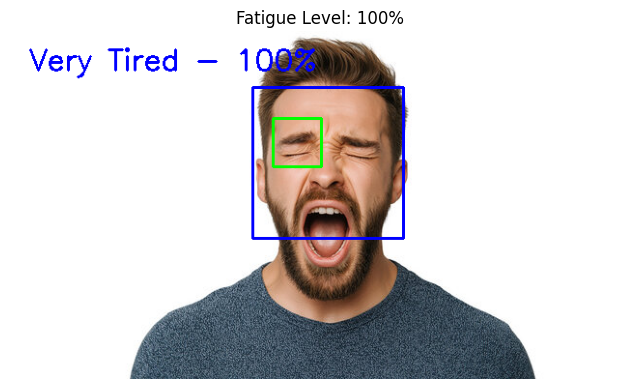

درجة الإرهاق: 100%
الحالة: Very Tired


In [6]:

image_path = 'Images/360_F_1596763925_th3Sc6MnnUm4w2kjv5W9iXvz9bdcpOZP.jpg'

run_project(image_path)